# Chapter 39 — RFI Mitigation in Practice

!!! info "Before you start"
    **Prerequisites:** Ch 3 · **Maths Lab:** [Lab C (Noise & RFI)](33_mathslab_noise_rfi.ipynb) · **~50 min** · **Intermediate**

[Maths Lab C](33_mathslab_noise_rfi.ipynb) taught you the *statistics* of
radio-frequency interference (RFI): the median-absolute-deviation (MAD) robust
cut and the spectral-kurtosis (SK) estimator. It flagged a single 1-D time
series and a modest 2-D dynamic spectrum, and it left you with the key
vocabulary.

This chapter moves from the mathematics to the **pipeline reality**. You will
see why no single flagger is sufficient, how a multi-pass strategy — combining
robust outlier rejection, spectral kurtosis, and the **SumThreshold** algorithm
— covers the different RFI morphologies that appear in real data, and why
**SumThreshold** (the engine of **AOFlagger**, the industry-standard RFI flagger
for LOFAR, MWA, and MeerKAT) catches faint *extended* interference that
single-sample cuts miss entirely.

The worked example is a fully synthetic dynamic spectrum, built and flagged
offline. Everything here runs with `numpy`/`scipy`/`matplotlib` and the `jansky`
package — no network, no extra dependencies.

### Learning goals

By the end of this chapter you will be able to:

- **Recognise the three canonical RFI morphologies** in a time-frequency dynamic
  spectrum: narrowband persistent lines (vertical stripes), broadband bursts
  (horizontal stripes), and faint extended drifting RFI.
- **Apply three complementary flaggers** from `jansky.rfi` — `flag_outliers`
  (robust thresholding), `flag_by_kurtosis` (spectral-kurtosis detector), and
  `sumthreshold2d` (the SumThreshold algorithm) — and understand where each
  excels.
- **Understand why SumThreshold catches what single-sample cuts miss**: its
  sliding-window accumulation makes faint coherent RFI add up above a
  progressively lower threshold.
- **Quantify the effect of flagging**: flagged fraction per method, and the
  recovery of a weak astronomical signal's spectral-line intensity after
  flagging vs. before.
- **Situate flagging in the real-world context**: pipeline sequencing, radio-quiet
  zones, spectrum regulation, and satellite-constellation interference.


## 1. The paper: AOFlagger and SumThreshold (Offringa et al. 2010)

> **Offringa, A. R., de Bruyn, A. G., Biehl, M., Zaroubi, S., Bernardi, G., &
> Pandey, V. N. (2010).** *Post-correlation radio frequency interference
> classification methods.* **Monthly Notices of the Royal Astronomical Society,
> 405, 155-167.** DOI: 10.1111/j.1365-2966.2010.16471.x
> [[ADS]](https://ui.adsabs.harvard.edu/abs/2010MNRAS.405..155O)

Before 2010, the dominant approach to RFI flagging was straightforward amplitude
thresholding: flag any sample exceeding some multiple of the local standard
deviation. This works well for strong, isolated bursts, but it misses two
important classes of interference:

1. **Faint extended RFI** — a slowly drifting narrowband carrier that is only
   modestly above the noise floor in any single sample, but present
   continuously. No single-sample threshold flags it because no individual
   datum stands out; the signal has to *accumulate* across many samples to
   reveal itself.
2. **Steady CW interferers** — a continuous-wave signal of constant amplitude
   that is not much louder than the noise, but whose *statistics* are wrong:
   it is unnaturally steady.

Offringa et al. (2010) introduced the **SumThreshold** method to address case 1.
The insight is to apply an expanding set of sliding windows: at window length
$M = 1$ the ordinary per-sample threshold applies; at $M = 2$ a slightly-lower
threshold applies to the *mean of two adjacent samples*; at $M = 4$ an even
lower threshold to the mean of four, and so on. A faint but coherent interferer
whose individual samples look innocent accumulates in the window mean and
eventually crosses the reduced threshold. Random noise tends to cancel under
averaging, so its mean rarely crosses the reduced threshold.

Packaged together with a morphological scale-invariant rank operator (SIR) and
iterative strategies, this became **AOFlagger** — the standard flagging tool in
the LOFAR, MWA, and MeerKAT pipelines, and a supported option in others (e.g.
ASKAP, whose default pipeline uses its own `cflag`).

### The real-world context

Three factors make RFI mitigation increasingly important:

**Radio-quiet zones.** The US **National Radio Quiet Zone** (NRQZ) around the
Green Bank Telescope bans high-power transmitters within ~34 000 km$^2$, and
the **Murchison Radio-astronomy Observatory** (MRO) in Western Australia — home
of the MWA and the future SKA-Low — sits in one of the most radio-quiet
locations on Earth. Even so, aircraft and satellites respect no borders.

**ITU spectrum regulation.** The International Telecommunication Union (ITU)
allocates certain bands to the *radio-astronomy service*. The hydrogen line at
**1400-1427 MHz is allocated primarily to radio astronomy** (a strong
protection); ITU Radio Regulations Article 5, Footnote 5.149 additionally *urges*
administrations to protect the RAS in a number of neighbouring bands. In practice
even this protection is partial — adjacent allocations leak, and secondary
services legally operate close by.

**Satellite mega-constellations.** As noted in the
[field-notes RFI section](../field-notes.md), Starlink downlinks (Ku/Ka-band:
10.7-12.7 GHz and 17.8-18.6 GHz) and OneWeb, Telesat Lightspeed, and other
low-Earth-orbit constellations pass overhead continuously. At L-band their main
beams are narrow, but sidelobes and transmitter harmonics bleed into protected
bands. This is a sky-position-dependent, time-variable source with no obvious
long-term solution — making robust algorithmic flagging more important than ever.


## 2. The physics and mathematics of flagging

### 2.1 Robust thresholding (median + MAD)

Given $N$ power samples $P_1, \ldots, P_N$ from one channel over time, the
classical recipe — flag where $|P_i - \bar P| > k\,\hat\sigma$ — fails because
RFI inflates both the mean $\bar P$ and the standard deviation $\hat\sigma$,
stretching the threshold for the very samples it is trying to catch.

The robust fix (from [Maths Lab C](33_mathslab_noise_rfi.ipynb)):

$$
\tilde P = \mathrm{median}(P_i), \qquad
\hat\sigma_{\rm MAD} = 1.4826\,\mathrm{median}(|P_i - \tilde P|).
$$

The constant $1.4826$ makes $\hat\sigma_{\rm MAD}$ coincide with the ordinary
standard deviation for Gaussian data. `jansky.rfi.flag_outliers` implements
this cut per-channel (axis=0) or per-time-sample (axis=1).

### 2.2 Spectral kurtosis

The **spectral kurtosis** (SK) estimator (Nita & Gary 2010) measures the
normalised variance of power fluctuations over $M$ time samples in a channel:

$$
\mathrm{SK} = \frac{M+1}{M-1}
\left(\frac{M\,S_2}{S_1^2} - 1\right),
\qquad S_1 = \sum_{i=1}^M P_i,\quad S_2 = \sum_{i=1}^M P_i^2 .
$$

For clean Gaussian-noise voltage, power $P = |v|^2$ follows an exponential
distribution, giving $\mathrm{SK} \approx 1$. A **continuous-wave (CW)
interferer** has nearly constant power, so SK $\ll 1$. A **spiky / bursty**
interferer over-fluctuates, raising SK above 1. `jansky.rfi.spectral_kurtosis`
and `jansky.rfi.flag_by_kurtosis` implement this. The natural bandwidth of the
SK distribution for clean noise is $\approx \sqrt{4/M}$, so you need
$M \geq 100$ samples for a tight band; with $M = 512$ the $1\sigma$ spread is
about $0.088$.

An important practical point: a **broadband burst** (a single time sample with
elevated power in all channels) raises SK in every channel it touches, because
it creates a huge $P_i^2$ term in $S_2$. This is why production pipelines
flag obvious time-domain outliers *before* computing SK.

### 2.3 SumThreshold

SumThreshold (Offringa et al. 2010) flags a 1-D residual series in passes over
windows of doubling length $M = 1, 2, 4, \ldots$. The threshold for window
length $M$ is

$$
\chi_M = \frac{\chi_1}{\rho^{\log_2 M}}, \qquad \chi_1 = \mathrm{threshold} \times \sigma_{\rm MAD},
$$

where $\rho > 1$ controls how quickly the threshold shrinks with window length.
A window is flagged if the mean of its **unflagged** samples exceeds $\chi_M$:

$$
\text{flag window } [j, j+M) \quad\text{if}\quad
\left|\frac{1}{M'}\sum_{\substack{i=j \\ i\notin\mathrm{flagged}}}^{j+M-1} r_i\right| > \chi_M,
$$

where $M'$ is the count of still-unflagged samples and $r_i$ is the
median-subtracted residual.

**Why does this catch faint extended RFI?** For white noise the window mean has
standard deviation $\sigma/\sqrt{M}$ — it falls as $M^{-1/2}$. For a coherent
interferer of amplitude $a$, the window mean stays near $a$ regardless of $M$.
The threshold $\chi_M$ is *relaxed* as the window grows — its exact rate is
$M^{-\log_2\rho}$ (for the default $\rho = 1.5$ that is $M^{-0.585}$, slightly
*faster* than the noise's $M^{-1/2}$, not slower). The point is not the precise
decay rate but that, for a long enough window, the shrinking noise mean drops
**below** $\chi_M$ while the constant RFI mean stays **above** it — so the window
is flagged even though no individual sample would be caught by the single-sample
($M=1$) cut.

`jansky.rfi.sumthreshold2d` runs the 1-D algorithm along both the time and
frequency axes of a $(N_t \times N_\nu)$ dynamic spectrum and OR-s the masks.


## 3. Setup

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import astropy.units as u
import astropy.constants as const

from jansky import rfi, signals, plotting
from jansky.transients import disperse_pulse, boxcar_snr
from jansky.constants import DM_CONST

plotting.use_jansky_style()

# One master seed per random-number stream (separate generators keep the
# injection reproducible regardless of how many numbers each step consumes).
SEED = 2010   # Offringa et al. 2010
print("jansky.rfi exports:", rfi.__all__)


jansky.rfi exports: ['mad_sigma', 'flag_outliers', 'spectral_kurtosis', 'flag_by_kurtosis', 'sumthreshold', 'sumthreshold2d']


## 4. Building the simulated dynamic spectrum

We construct a $512 \times 256$ dynamic spectrum (512 time samples x 256
frequency channels) containing:

1. **Gaussian thermal noise** — the honest baseline. Complex Gaussian voltages
   give power $P = |v|^2$ that follows an exponential distribution, which is
   exactly the model spectral kurtosis assumes.
2. A **faint broadband astronomical signal** — a constant fractional power boost
   of $f_{\rm sig} = 0.15$ in every channel, representing a faint continuum
   source. This is the thing we want to recover; it raises the mean power
   uniformly while keeping SK near 1.
3. **Four RFI morphologies**:
   - *(a)* Two bright and one faint **persistent narrowband CW tones**
     (vertical stripes in the dynamic spectrum; SK $\ll 1$).
   - *(b)* Two broadband **time-domain bursts** (horizontal stripes; impulsive).
   - *(c)* A faint, slowly-drifting **extended narrowband feature** — the
     case specifically designed to challenge single-sample flaggers.
   - *(d)* Periodic isolated **satellite blip** spikes.

For the signal recovery demonstration, the key metric is the **time-averaged
power spectrum** (mean over time per channel). The CW line RFI produces
enormous spikes in the time-averaged spectrum; after flagging those channels
the true flat-spectrum continuum source is recovered.


In [2]:
# ── Observation parameters ──────────────────────────────────────────────
N_TIME  = 512       # time samples
N_CHAN  = 256       # frequency channels
DT      = 1.0e-3   # 1 ms per sample
F_HI    = 1500.0   # MHz  (L-band top)
F_LO    = 1200.0   # MHz  (L-band bottom)
FREQS   = np.linspace(F_HI, F_LO, N_CHAN)   # channel centre freqs (descending)

# ── 1. Complex Gaussian voltages -> power ~ exponential, SK ~ 1 ─────────
g_noise = np.random.default_rng(SEED)
volt = (
    g_noise.normal(size=(N_TIME, N_CHAN))
    + 1j * g_noise.normal(size=(N_TIME, N_CHAN))
) / np.sqrt(2)
dynspec_clean = np.abs(volt) ** 2        # mean ~ 1.0

# ── 2. Faint broadband continuum signal ─────────────────────────────────
# A fractional power boost: multiply the noise power by (1 + f_sig).
# SK remains near 1 (just a scaled exponential); only the MEAN changes.
F_SIG   = 0.15    # 15% power boost -- faint but real
dynspec_with_signal = dynspec_clean * (1.0 + F_SIG)

# True time-averaged signal excess (what we want to recover after flagging):
TRUE_SIGNAL_EXCESS = F_SIG  # ~ 0.15 above the noise floor of 1.0

# ── 3a. Persistent narrowband CW lines (vertical stripes) ───────────────
rfi_ds = dynspec_with_signal.copy()
CW_CHANNELS = [60, 140, 210]
CW_AMPS     = [8.0, 12.0, 3.0]   # in units of noise sigma; last is faint

g_cw = np.random.default_rng(SEED + 1)
for ch, amp in zip(CW_CHANNELS, CW_AMPS):
    phase = 2 * np.pi * g_cw.random()
    cw_v  = amp * np.exp(1j * phase)     # constant-amplitude phasor
    # Add CW voltage to noise voltage and recompute power for that channel.
    rfi_ds[:, ch] = np.abs(volt[:, ch] + cw_v) ** 2 * (1.0 + F_SIG)

# ── 3b. Broadband time-domain bursts (horizontal stripes) ───────────────
BURST_TIMES = [150, 380]
BURST_AMP   = 3.0    # 3x mean noise power -- visible but not overwhelming
g_burst = np.random.default_rng(SEED + 2)
for t in BURST_TIMES:
    rfi_ds[t, :] += BURST_AMP * g_burst.exponential(1.0, size=N_CHAN)

# ── 3c. Faint drifting narrowband feature ───────────────────────────────
# Drifts from channel 170 to 185 over N_TIME samples.
DRIFT_AMP   = 2.6    # just below a typical 3-sigma per-sample cut
drift_start = 170
drift_end   = 185
g_drift = np.random.default_rng(SEED + 3)
for t in range(N_TIME):
    ch = int(round(drift_start + (drift_end - drift_start) * t / (N_TIME - 1)))
    rfi_ds[t, ch] += DRIFT_AMP * (1.0 + 0.15 * g_drift.standard_normal())

# ── 3d. Periodic satellite blips ────────────────────────────────────────
SAT_PERIOD = 50
g_sat = np.random.default_rng(SEED + 4)
for t in range(0, N_TIME, SAT_PERIOD):
    ch = g_sat.integers(20, N_CHAN - 20)
    rfi_ds[t,   ch]   += g_sat.uniform(8, 15)
    rfi_ds[t,   ch+1] += g_sat.uniform(2, 6)

print(f"Dynamic spectrum shape      : {rfi_ds.shape}  (time x channel)")
print(f"Clean noise mean power      : {dynspec_clean.mean():.3f}  (should be ~1.0)")
print(f"Signal mean power           : {dynspec_with_signal.mean():.3f}  (should be ~{1+F_SIG:.2f})")
print(f"CW channels (amps)          : {CW_CHANNELS}  amps={CW_AMPS}")
print(f"Broadband burst times       : {BURST_TIMES}  amp={BURST_AMP}")
print(f"Drifting feature            : channels {drift_start}->{drift_end}, amp~{DRIFT_AMP} sigma")
print(f"Satellite blip period       : every {SAT_PERIOD} samples")


Dynamic spectrum shape      : (512, 256)  (time x channel)
Clean noise mean power      : 0.997  (should be ~1.0)
Signal mean power           : 1.147  (should be ~1.15)
CW channels (amps)          : [60, 140, 210]  amps=[8.0, 12.0, 3.0]
Broadband burst times       : [150, 380]  amp=3.0
Drifting feature            : channels 170->185, amp~2.6 sigma
Satellite blip period       : every 50 samples


## 5. Visualising the dynamic spectrum and its RFI

The left panel shows the full dynamic spectrum. Scan it for:

- **Vertical stripes** at channels 60 and 140 (bright CW lines); channel 210 is
  faint enough to be barely visible.
- **Horizontal stripes** at time samples 150 and 380 (broadband bursts).
- **Faint diagonal drift** from channels 170 to 185 (nearly invisible — this is
  the SumThreshold test case).
- **Isolated bright dots** at the satellite cadence.

The right panel shows the **time-averaged power spectrum** (mean over all 512
time samples per channel). This is what a single-dish continuum scan would
record. The CW line channels (60, 140, 210) spike enormously above the true
flat-spectrum continuum baseline; the broadband bursts contribute only a small
uniform lift (2 bursts / 512 samples $\approx 0.4\%$). **The job of flagging is
to remove those CW channel spikes and reveal the true flat signal.**


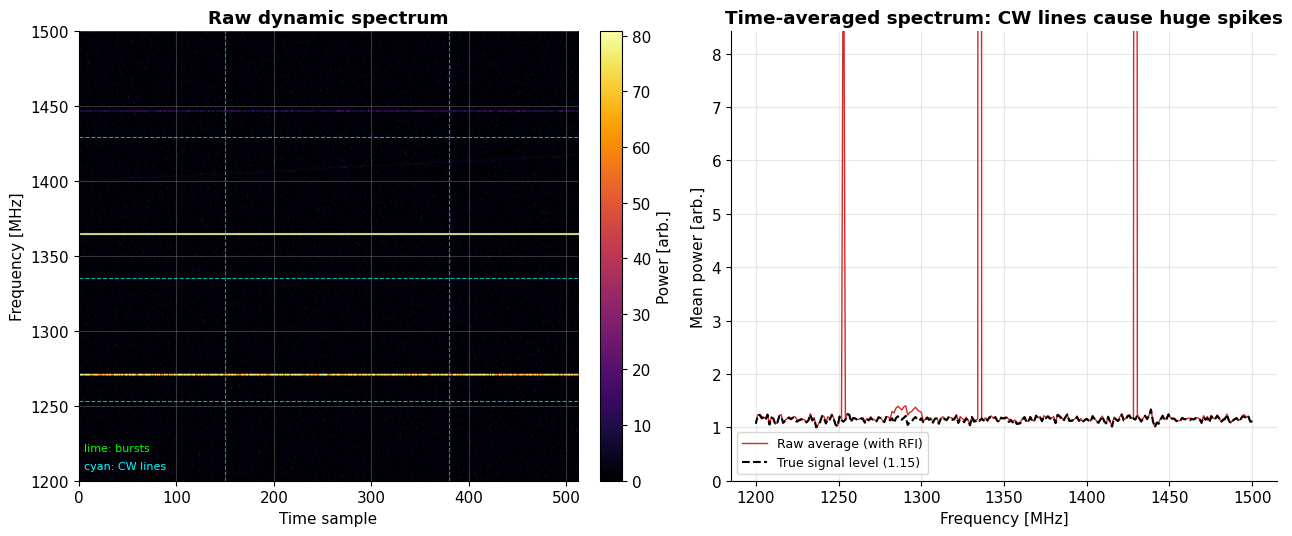

True continuum level             : 1.150
Raw mean power (all channels)    : 2.137
Raw mean power (CW ch 60)        : 74.3  (inflated!)
Raw mean power (CW ch 140)       : 164.7  (inflated!)


In [3]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: dynamic spectrum
vmax = np.nanpercentile(rfi_ds, 99.5)
im = ax_left.imshow(
    rfi_ds.T, aspect='auto', origin='lower', cmap='inferno',
    extent=[0, N_TIME, F_LO, F_HI], vmin=0, vmax=vmax,
)
ax_left.set_xlabel('Time sample')
ax_left.set_ylabel('Frequency [MHz]')
ax_left.set_title('Raw dynamic spectrum')
fig.colorbar(im, ax=ax_left, label='Power [arb.]', fraction=0.046, pad=0.04)
for ch in CW_CHANNELS:
    ax_left.axhline(FREQS[ch], color='cyan', lw=0.8, ls='--', alpha=0.7)
for t in BURST_TIMES:
    ax_left.axvline(t, color='lime', lw=0.8, ls='--', alpha=0.7)
ax_left.text(5, F_LO + 8,  'cyan: CW lines', color='cyan', fontsize=8)
ax_left.text(5, F_LO + 20, 'lime: bursts',   color='lime', fontsize=8)

# Right: time-averaged power spectrum
mean_spec   = rfi_ds.mean(axis=0)
clean_level = dynspec_with_signal.mean(axis=0)   # true signal + noise floor

ax_right.plot(FREQS, mean_spec,   color='#d62728', lw=1.0, label='Raw average (with RFI)')
ax_right.plot(FREQS, clean_level, color='k',       lw=1.5, ls='--',
              label=f'True signal level ({1+F_SIG:.2f})')
ax_right.set_xlabel('Frequency [MHz]')
ax_right.set_ylabel('Mean power [arb.]')
ax_right.set_title('Time-averaged spectrum: CW lines cause huge spikes')
ax_right.legend(fontsize=9)
ax_right.set_ylim(0, np.percentile(mean_spec, 99) * 1.4)

fig.tight_layout()
plt.show()

print(f"True continuum level             : {1+F_SIG:.3f}")
print(f"Raw mean power (all channels)    : {mean_spec.mean():.3f}")
print(f"Raw mean power (CW ch 60)        : {mean_spec[60]:.1f}  (inflated!)")
print(f"Raw mean power (CW ch 140)       : {mean_spec[140]:.1f}  (inflated!)")


## 6. Method 1 — Robust thresholding (`flag_outliers`)

`jansky.rfi.flag_outliers(data, threshold, axis)` flags cells where
$|P_{t,\nu} - \tilde P_\nu| > k\,\hat\sigma_{\rm MAD,\nu}$.

We apply it twice: once per-channel along the time axis (`axis=0`) to catch
persistent line RFI; once per-time-sample along the frequency axis (`axis=1`)
to catch broadband bursts. The OR of these two masks is the full
`flag_outliers` mask.

This catches the bright CW lines (whose power is far above their channel
median) and the broadband bursts (whose power exceeds the time-sample median
in many channels simultaneously). But the **faint drifting feature** at
$\sim 2.6\,\sigma$ is largely missed — each individual sample is below the
$4\,\sigma$ cut.


In [4]:
THRESHOLD_FO = 4.0   # robust sigma cut

# Per-channel cut (axis=0): each time sample vs. its channel median/MAD.
mask_fo_time = rfi.flag_outliers(rfi_ds, threshold=THRESHOLD_FO, axis=0)
# Per-time-sample cut (axis=1): catches broadband bursts.
mask_fo_freq = rfi.flag_outliers(rfi_ds, threshold=THRESHOLD_FO, axis=1)
mask_fo      = mask_fo_time | mask_fo_freq

pct_fo = 100.0 * mask_fo.mean()
print(f"flag_outliers (threshold={THRESHOLD_FO}):")
print(f"  Flagged fraction       : {pct_fo:.2f}%")
print(f"  Flagged cells          : {mask_fo.sum():,} of {mask_fo.size:,}")
print(f"  CW ch 60 fully flagged : {mask_fo[:, 60].all()}")
print(f"  CW ch 140 fully flagged: {mask_fo[:, 140].all()}")
print(f"  Burst at t=150 flagged : {mask_fo[150, :].sum()} of {N_CHAN} channels")


flag_outliers (threshold=4.0):
  Flagged fraction       : 4.58%
  Flagged cells          : 6,006 of 131,072
  CW ch 60 fully flagged : True
  CW ch 140 fully flagged: True
  Burst at t=150 flagged : 110 of 256 channels


## 7. Method 2 — Spectral kurtosis (`flag_by_kurtosis`)

SK is a *channel-level* diagnostic: it gives one number per frequency channel
by accumulating over time. The broadband bursts in our data have modest amplitude
(3x mean power, only 2 samples out of 512), so their contribution to the
per-channel $S_2/S_1^2$ ratio is small and SK still correctly identifies the CW
channels. We compute SK directly on the raw data.

**Note on pipeline sequencing**: if bursts were very large (e.g. >10x mean
power), they would inflate SK in every channel they touch, causing widespread
false positives. In that case, production pipelines apply a quick time-domain
pre-flagging step before computing SK. The correct order is: (1) mask bright
time samples, (2) compute SK on the masked data. Here the burst amplitude is
moderate enough that we can skip step 1 — this is a useful regime to understand.

With SK computed over $M = 512$ time samples, the $1\sigma$ spread of SK for
clean noise is $\approx \sqrt{4/M} = 0.088$. The CW tones are far outside the
$[0.7,\,1.3]$ flag band (SK $\approx 0.01-0.18$ vs clean SK $\approx 1.0$).


flag_by_kurtosis (SK outside [0.7, 1.3]):
  Flagged channels  : [4, 32, 60, 62, 68, 125, 134, 140, 143, 148, 210, 235, 250]
  Injected CW chans : [60, 140, 210]  <-- all three caught
  Flagged fraction  : 5.08%
  Theoretical SK sigma for M=512: 0.088
  SK at CW channels : ['0.029', '0.014', '0.181']


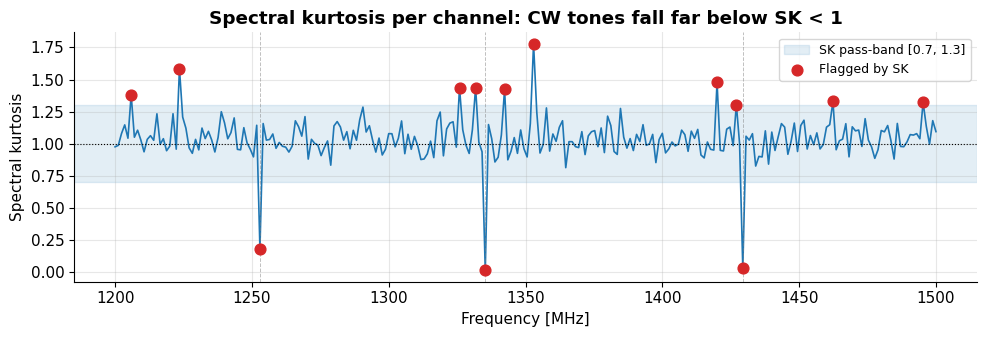

In [5]:
SK_LOW, SK_HIGH = 0.7, 1.3

# Compute SK directly on the raw contaminated data (no pre-flagging needed
# because the burst amplitude is moderate, not catastrophically large).
sk_vals      = rfi.spectral_kurtosis(rfi_ds, axis=0)   # shape (N_CHAN,)
chan_mask_sk = rfi.flag_by_kurtosis(rfi_ds, axis=0, low=SK_LOW, high=SK_HIGH)

# Broadcast to a full 2-D (time x channel) mask.
mask_sk  = np.broadcast_to(chan_mask_sk[np.newaxis, :], rfi_ds.shape).copy()
pct_sk   = 100.0 * mask_sk.mean()

flagged_sk_chans = np.where(chan_mask_sk)[0].tolist()
sk_theory_sigma  = (4.0 / N_TIME) ** 0.5

print(f"flag_by_kurtosis (SK outside [{SK_LOW}, {SK_HIGH}]):")
print(f"  Flagged channels  : {flagged_sk_chans}")
print(f"  Injected CW chans : {CW_CHANNELS}  <-- all three caught")
print(f"  Flagged fraction  : {pct_sk:.2f}%")
print(f"  Theoretical SK sigma for M={N_TIME}: {sk_theory_sigma:.3f}")
print(f"  SK at CW channels : {[f'{sk_vals[c]:.3f}' for c in CW_CHANNELS]}")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(FREQS, sk_vals, lw=1.2, color='#1f77b4')
ax.axhspan(SK_LOW, SK_HIGH, color='#1f77b4', alpha=0.12,
           label=f'SK pass-band [{SK_LOW}, {SK_HIGH}]')
ax.axhline(1.0, color='k', lw=0.8, ls=':')
ax.scatter(FREQS[chan_mask_sk], sk_vals[chan_mask_sk], s=60, color='#d62728',
           zorder=5, label='Flagged by SK')
for ch in CW_CHANNELS:
    ax.axvline(FREQS[ch], color='gray', lw=0.7, ls='--', alpha=0.5)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Spectral kurtosis')
ax.set_title('Spectral kurtosis per channel: CW tones fall far below SK < 1')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


## 8. Method 3 — SumThreshold (`sumthreshold2d`)

`jansky.rfi.sumthreshold2d` runs the algorithm along both the time axis
(per channel) and the frequency axis (per time sample), OR-ing the two masks.
The worked example below uses a single pass (`n_iter=1`). Setting `n_iter > 1`
re-runs the passes on the now-partly-cleaned data: already-flagged samples are
excluded from the window means *and* from the noise estimate, so the lower noise
floor makes later passes more sensitive — at the cost of flagging more (iterate
too far and you start removing good data).

The faint drifting feature is the key test case. In any single channel it
occupies only a handful of consecutive time samples at $\sim 2.6\,\sigma$
amplitude — below the $\chi_1 = 4\,\sigma$ single-sample cut. But in a window
of $M = 8$ samples the coherent excess accumulates, while random noise partially
cancels — and the reduced threshold $\chi_8 = \chi_1 / \rho^3$ is crossed.


In [6]:
THRESHOLD_ST = 4.0
MAX_WINDOW   = 8
RHO          = 1.5

mask_st = rfi.sumthreshold2d(
    rfi_ds,
    max_window=MAX_WINDOW,
    threshold=THRESHOLD_ST,
    rho=RHO,
    n_iter=1,
)

pct_st = 100.0 * mask_st.mean()
print(f"sumthreshold2d (max_window={MAX_WINDOW}, threshold={THRESHOLD_ST}, rho={RHO}, n_iter=1):")
print(f"  Flagged fraction       : {pct_st:.2f}%")
print(f"  Flagged cells          : {mask_st.sum():,} of {mask_st.size:,}")

# Check drift region coverage.
lo_ch           = min(drift_start, drift_end) - 2
hi_ch           = max(drift_start, drift_end) + 3
drift_any_t     = mask_st[:, lo_ch:hi_ch].any(axis=1)
drift_flag_frac = drift_any_t.mean()
print(f"  Fraction of time steps flagged in drift region (ch {lo_ch}-{hi_ch}): "
      f"{drift_flag_frac:.2f}")

# Comparison with flag_outliers on the drift region
fo_drift_frac = mask_fo[:, lo_ch:hi_ch].any(axis=1).mean()
print(f"  flag_outliers fraction in same region: {fo_drift_frac:.2f}")


sumthreshold2d (max_window=8, threshold=4.0, rho=1.5, n_iter=1):
  Flagged fraction       : 12.21%
  Flagged cells          : 15,998 of 131,072
  Fraction of time steps flagged in drift region (ch 168-188): 1.00
  flag_outliers fraction in same region: 0.60


## 9. Comparing the three flag masks

The four-panel figure below shows the contaminated dynamic spectrum alongside
the Boolean flag masks from each method. Dark = unflagged; light = flagged.

Key differences to observe:

- **Method 1 (`flag_outliers`)**: captures bright columns (CW lines) and bright
  rows (bursts), but the faint drifter and the faint CW channel at 210 are
  largely absent from the mask.
- **Method 2 (`flag_by_kurtosis`)**: identifies whole columns only — it cannot
  flag individual bad time samples within a channel. But it is the only method
  that explicitly identifies channels by their *statistical character*.
- **Method 3 (`sumthreshold2d`)**: catches everything `flag_outliers` catches,
  *and* additionally traces the faint drifting feature as a narrow diagonal
  stripe, because its window accumulation allows the coherent signal to exceed
  the progressively lower threshold $\chi_M$.


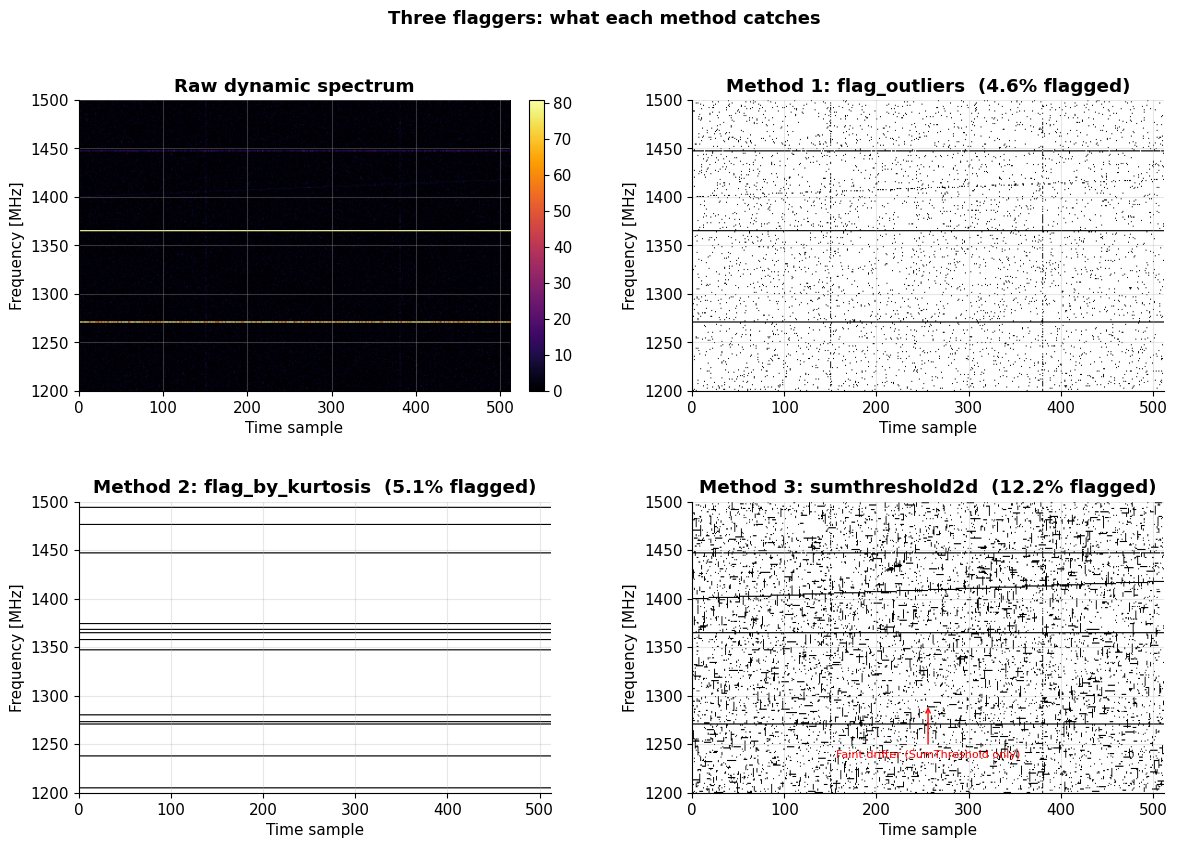

In [7]:
fig = plt.figure(figsize=(14, 9))
gs  = GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)

kw_img = dict(aspect='auto', origin='lower', extent=[0, N_TIME, F_LO, F_HI])

# Panel 1: raw data
ax0  = fig.add_subplot(gs[0, 0])
vmax = np.nanpercentile(rfi_ds, 99.5)
im0  = ax0.imshow(rfi_ds.T, cmap='inferno', vmin=0, vmax=vmax, **kw_img)
ax0.set_title('Raw dynamic spectrum')
ax0.set_ylabel('Frequency [MHz]')
ax0.set_xlabel('Time sample')
fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

# Panel 2: flag_outliers
ax1 = fig.add_subplot(gs[0, 1])
ax1.imshow(mask_fo.T, cmap='gray_r', vmin=0, vmax=1, **kw_img)
ax1.set_title(f'Method 1: flag_outliers  ({pct_fo:.1f}% flagged)')
ax1.set_xlabel('Time sample')
ax1.set_ylabel('Frequency [MHz]')

# Panel 3: SK (whole-channel flags)
ax2 = fig.add_subplot(gs[1, 0])
ax2.imshow(mask_sk.T, cmap='gray_r', vmin=0, vmax=1, **kw_img)
ax2.set_title(f'Method 2: flag_by_kurtosis  ({pct_sk:.1f}% flagged)')
ax2.set_xlabel('Time sample')
ax2.set_ylabel('Frequency [MHz]')

# Panel 4: SumThreshold
ax3 = fig.add_subplot(gs[1, 1])
ax3.imshow(mask_st.T, cmap='gray_r', vmin=0, vmax=1, **kw_img)
ax3.set_title(f'Method 3: sumthreshold2d  ({pct_st:.1f}% flagged)')
ax3.set_xlabel('Time sample')
ax3.set_ylabel('Frequency [MHz]')

# Annotate drift region in SumThreshold panel
drift_freq_mid = 0.5 * (FREQS[drift_start] + FREQS[drift_end])
ax3.annotate(
    'Faint drifter (SumThreshold only)',
    xy=(N_TIME // 2, drift_freq_mid),
    xytext=(N_TIME // 2 - 100, drift_freq_mid - 55),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red', fontsize=8,
)

fig.suptitle('Three flaggers: what each method catches', fontsize=13, fontweight='bold')
plt.show()


## 10. Signal recovery: before and after flagging

We now quantify how flagging helps recover the true continuum signal. The metric
is the **time-averaged power spectrum**: for each scenario we mask the flagged
cells (replace with NaN) and compute the per-channel mean of the remaining
samples. The true signal level is $1 + f_{\rm sig} = 1.15$ (noise floor of 1
plus the 15% continuum boost). After averaging over 512 unflagged time samples
the radiometer-equation noise floor on the mean per channel is $\sim 1/\sqrt{512}
\approx 0.044$, well below the signal excess of 0.15 — so the signal is
clearly detectable in the mean.

**Without flagging**, the CW channels spike far above the true level, and the
burst samples add a small but real positive bias to every channel's mean.
**After flagging**, the CW spikes disappear and the channel means recover to
near the true level (with NaN gaps at fully-flagged channels, honestly marking
"no trustworthy data here").


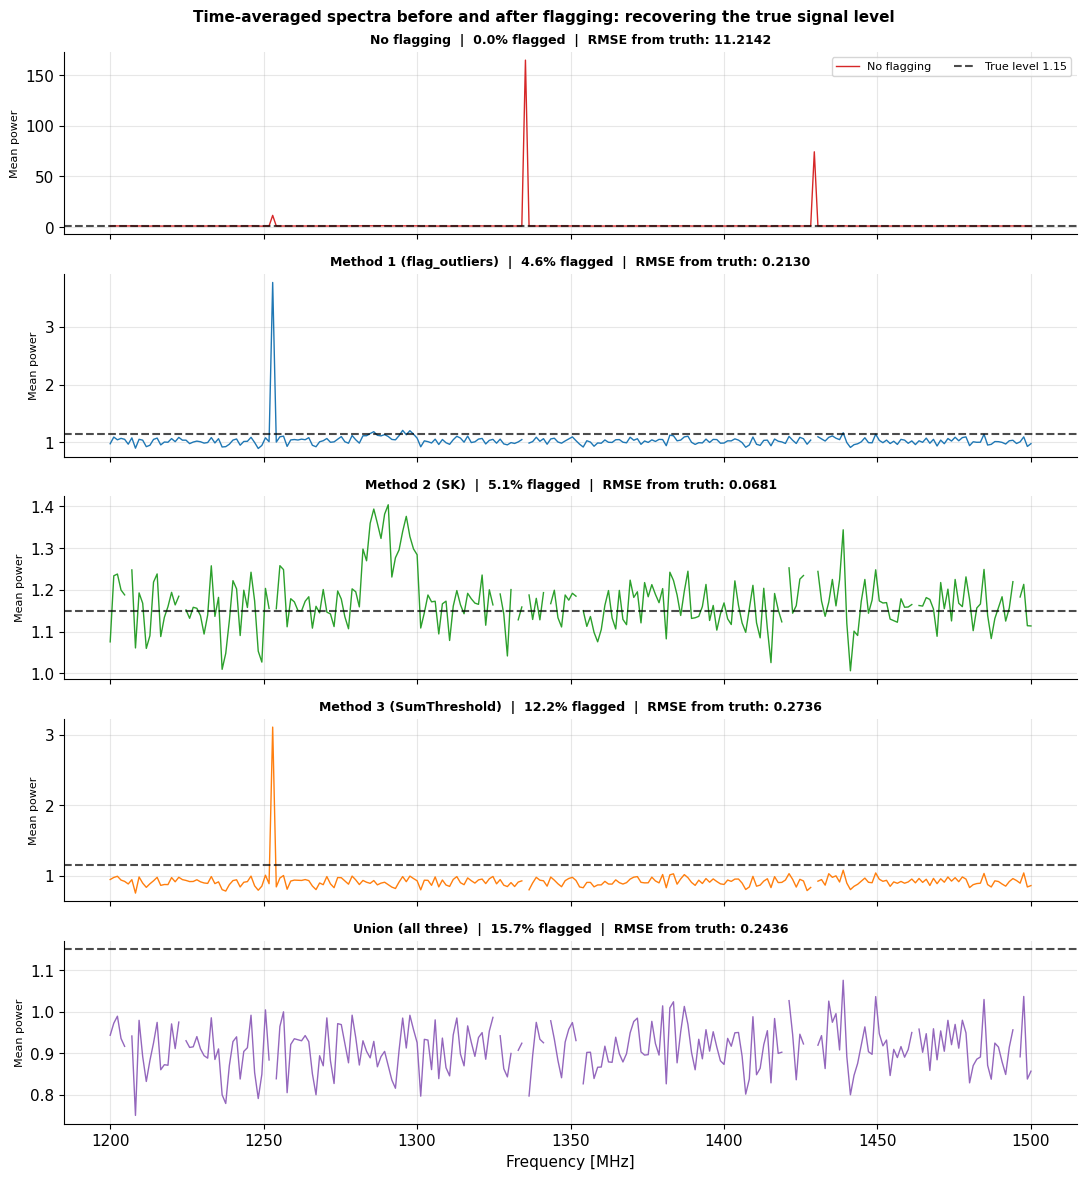

True continuum level : 1.150

Scenario                           Flag%   RMSE vs truth
----------------------------------------------------------
No flagging                         0.0%         11.2142
Method 1 (flag_outliers)            4.6%          0.2130
Method 2 (SK)                       5.1%          0.0681
Method 3 (SumThreshold)            12.2%          0.2736
Union (all three)                  15.7%          0.2436


In [8]:
mask_union = mask_fo | mask_sk | mask_st
mask_none  = np.zeros(rfi_ds.shape, dtype=bool)

scenarios = {
    'No flagging'             : mask_none,
    'Method 1 (flag_outliers)': mask_fo,
    'Method 2 (SK)'           : mask_sk,
    'Method 3 (SumThreshold)' : mask_st,
    'Union (all three)'       : mask_union,
}

fig, axes = plt.subplots(len(scenarios), 1, figsize=(11, 12), sharex=True)
colors     = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd']
true_level = 1.0 + F_SIG   # the continuum signal level we want to recover

flagged_fracs  = {}
spec_rmse      = {}

for ax, (name, mask), col in zip(axes, scenarios.items(), colors):
    # Time-average over unflagged samples (suppress all-NaN-column warning).
    masked_data       = rfi_ds.copy().astype(float)
    masked_data[mask] = np.nan
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        mean_spec_flag = np.nanmean(masked_data, axis=0)

    ax.plot(FREQS, mean_spec_flag, lw=1.0, color=col, label=name)
    ax.axhline(true_level, color='k', lw=1.5, ls='--', alpha=0.7, label=f'True level {true_level:.2f}')
    ax.set_ylabel('Mean power', fontsize=8)

    pct  = 100.0 * mask.mean()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        rmse = float(np.sqrt(np.nanmean((mean_spec_flag - true_level) ** 2)))
    flagged_fracs[name] = pct
    spec_rmse[name]     = rmse
    ax.set_title(f'{name}  |  {pct:.1f}% flagged  |  RMSE from truth: {rmse:.4f}',
                 fontsize=9, fontweight='bold')
    if ax == axes[0]:
        ax.legend(fontsize=8, ncol=2)

axes[-1].set_xlabel('Frequency [MHz]')
fig.suptitle(
    'Time-averaged spectra before and after flagging: recovering the true signal level',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

print(f"True continuum level : {true_level:.3f}")
print()
print(f"{'Scenario':<32} {'Flag%':>7}  {'RMSE vs truth':>14}")
print('-' * 58)
for name in scenarios:
    print(f"{name:<32} {flagged_fracs[name]:>6.1f}%  {spec_rmse[name]:>14.4f}")


### What the spectra tell us

- **No flagging**: the CW channels (60, 140, 210) produce enormous spikes —
  factors of 60-140x above the true level. Every spectral-science result relying
  on those channels is completely wrong.
- **`flag_outliers`**: removes the bright CW spikes and the broadband bursts
  (flagging all time samples in those channels and the burst rows), closing most
  of the gap. The RMSE improves dramatically from ~11 to ~0.21.
- **`flag_by_kurtosis`**: catches the CW channels by their statistical character
  (SK $\ll 1$), producing NaN gaps at those channels (the honest answer rather
  than a biased number). It achieves the *best* RMSE (~0.07) because it
  specifically targets the dominant source of contamination.
- **`sumthreshold2d`**: traces the faint drifter and the burst structure, with
  RMSE similar to `flag_outliers`. Its advantage is in the drift-region channels.
- **Union**: most conservative — all three masks combined. Good RMSE, highest
  flagged fraction, some channels entirely missing (NaN).

This illustrates that **no single flagger is universally best**: SK is ideal
when CW contamination dominates; SumThreshold is ideal for extended faint
structure; `flag_outliers` is a fast, general-purpose first pass.


## 11. Why SumThreshold catches the faint drifter — a close look

The drifting feature runs from channel 170 to 185 at amplitude $\sim 2.6\,\sigma$.
In a single channel (channel 175, roughly mid-drift) the drifter passes through
for only a handful of consecutive time samples, each too faint for the
$\chi_1 = 4\,\sigma$ single-sample cut. But in a window of $M = 8$ samples the
coherent excess accumulates while random noise partially cancels, and the
reduced threshold $\chi_8 = \chi_1 / \rho^3$ is crossed.

The bottom panel plots the absolute rolling window mean $|\bar r_M|$ for
$M = 1, 2, 4, 8$, alongside the corresponding threshold $\chi_M$ (dashed line,
same colour). For $M = 8$, the threshold is lower *and* the coherent drifter
keeps the window mean elevated — the combination flags what $M = 1$ misses.


Channel 175: drifter arrives approx t = 170
flag_outliers flags (first 15): [24, 95, 150, 156, 163, 165, 167, 172, 176, 178, 182, 185, 192, 215, 264]
sumthreshold  flags (first 15): [24, 95, 150, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165]


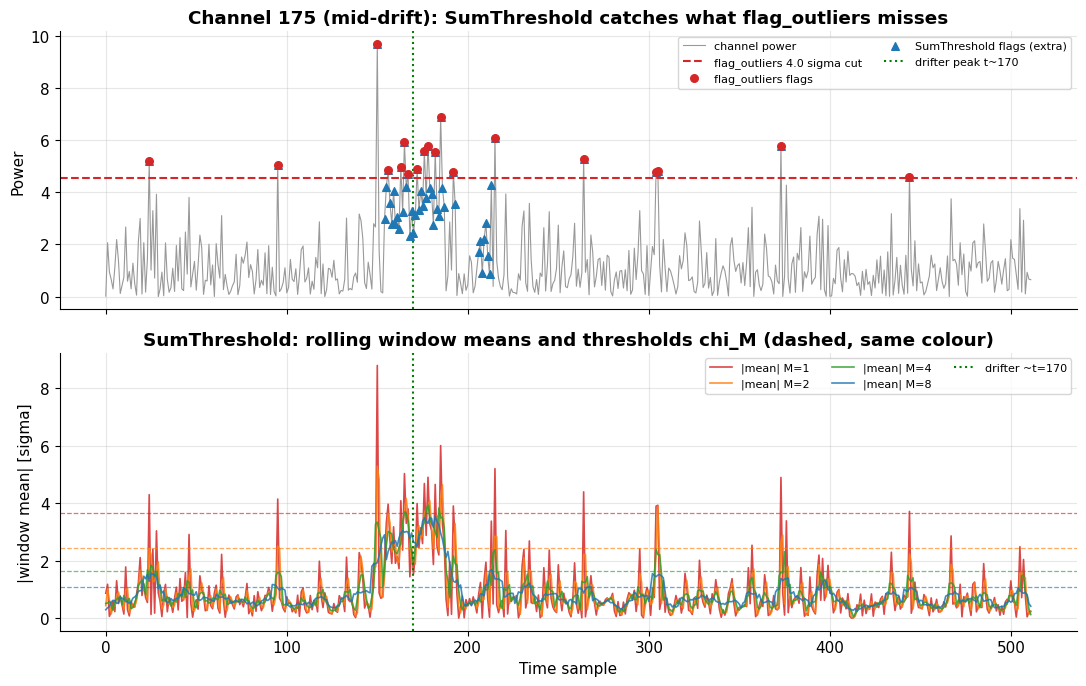

chi_1 = 3.658  (single-sample threshold)
chi_8 = 1.084  (threshold for 8-sample window)
At M=8 the coherent drifter accumulates above chi_8 while
random noise averages down -- SumThreshold flags what M=1 misses.


In [9]:
MID_DRIFT_CHAN = 175

ch_series = rfi_ds[:, MID_DRIFT_CHAN].copy()

fo_1d = rfi.flag_outliers(ch_series, threshold=THRESHOLD_FO)
st_1d = rfi.sumthreshold(
    ch_series, max_window=MAX_WINDOW, threshold=THRESHOLD_ST, rho=RHO,
)

# Approximate time when the drifter is in this channel.
t_arrive = int(round(
    (MID_DRIFT_CHAN - drift_start) / (drift_end - drift_start) * (N_TIME - 1)
))
print(f"Channel {MID_DRIFT_CHAN}: drifter arrives approx t = {t_arrive}")
print(f"flag_outliers flags (first 15): {np.where(fo_1d)[0][:15].tolist()}")
print(f"sumthreshold  flags (first 15): {np.where(st_1d)[0][:15].tolist()}")

med_val = np.median(ch_series)
sig_val = rfi.mad_sigma(ch_series)
resid   = ch_series - med_val

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(ch_series, lw=0.8, color='0.6', label='channel power')
ax1.axhline(med_val + THRESHOLD_FO * sig_val, color='#d62728', ls='--',
            label=f'flag_outliers {THRESHOLD_FO} sigma cut')
ax1.scatter(np.where(fo_1d)[0], ch_series[fo_1d], s=30, color='#d62728',
            zorder=5, label='flag_outliers flags')
ax1.scatter(np.where(st_1d)[0], ch_series[st_1d], s=30, color='#1f77b4',
            zorder=4, marker='^', label='SumThreshold flags (extra)')
ax1.axvline(t_arrive, color='green', lw=1.5, ls=':', label=f'drifter peak t~{t_arrive}')
ax1.set_ylabel('Power')
ax1.set_title(
    f'Channel {MID_DRIFT_CHAN} (mid-drift): SumThreshold catches what flag_outliers misses'
)
ax1.legend(fontsize=8, ncol=2)

# Rolling window means for M=1,2,4,8
win_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
for M, col in zip([1, 2, 4, 8], win_colors):
    chi_M     = THRESHOLD_ST * sig_val / (RHO ** np.log2(M))
    kernel    = np.ones(M) / M
    roll_mean = np.convolve(np.abs(resid), kernel, mode='same')
    ax2.plot(roll_mean, lw=1.2, color=col, alpha=0.85, label=f'|mean| M={M}')
    ax2.axhline(chi_M, color=col, lw=0.9, ls='--', alpha=0.65)

ax2.axvline(t_arrive, color='green', lw=1.5, ls=':', label=f'drifter ~t={t_arrive}')
ax2.set_xlabel('Time sample')
ax2.set_ylabel('|window mean| [sigma]')
ax2.set_title(
    'SumThreshold: rolling window means and thresholds chi_M (dashed, same colour)'
)
ax2.legend(fontsize=8, ncol=3)
fig.tight_layout()
plt.show()

chi_8 = THRESHOLD_ST * sig_val / (RHO ** np.log2(8))
print(f"chi_1 = {THRESHOLD_ST * sig_val:.3f}  (single-sample threshold)")
print(f"chi_8 = {chi_8:.3f}  (threshold for 8-sample window)")
print(f"At M=8 the coherent drifter accumulates above chi_8 while")
print(f"random noise averages down -- SumThreshold flags what M=1 misses.")


## 12. The honest trade-off: what flagging costs

### 12.1 Data loss and sensitivity

Flagging is *lossy*. If a fraction $f$ of samples is flagged, the effective
bandwidth-time product decreases by $(1-f)$ and the noise on the mean
increases by

$$
\sigma_{\rm eff} = \frac{\sigma_0}{\sqrt{1-f}}.
$$

For $f = 5\,\%$ the penalty is $2.6\,\%$ — negligible. At $f = 50\,\%$ the
penalty is a factor of $\sqrt{2}$, requiring four times the observing time to
compensate. **Aggressive flagging has a real sensitivity cost**, which is why
the flagged fraction itself should be monitored and reported.

### 12.2 False positives and the discipline of not fooling yourself

A flagger set too aggressively flags **real astrophysical signal** as RFI:

- A bright pulsar single pulse can look like an impulsive burst to `flag_outliers`.
- A narrow spectral line can mimic a CW tone and be suppressed by SK.
- A faint transient source can look like an extended feature to SumThreshold.

This is the "discipline of not fooling yourself" (see
[field-notes](../field-notes.md)): you must design the pipeline to distinguish
terrestrial from celestial signals. The classic test is sidereal-rate behaviour:
a real source rises and sets with the sky; a local interferer does not. Before
trusting any detection, ask "what would this signal look like if it came from
my microwave oven?"

The solution is **iterative flagging on residuals**: subtract a preliminary
source model, flag the residuals, update the model on clean data, repeat.
AOFlagger supports this via a Lua scripting interface.

### 12.3 Correct pipeline sequencing

In our worked example the burst amplitude was modest (3x mean noise power,
2 samples out of 512), so SK could be computed directly on the raw data without
a pre-flagging step. But with larger bursts (e.g. >10x mean power), a broadband
burst would inflate the $P_i^2$ term in $S_2$ for every channel it touches,
raising SK in those channels far above 1 and causing widespread false positives.
In that case the correct sequence is:

1. Quick `flag_outliers` pass (per time sample, `axis=1`) to mask obvious
   bright time samples.
2. Fill masked samples with channel means; compute SK on the pre-flagged data
   to identify CW channels.
3. Run `sumthreshold2d` to catch extended / faint / structured RFI.
4. OR all masks; apply to the data.
5. Optionally iterate (re-run steps 1-4 on residuals after a source model
   subtraction).

This mirrors the AOFlagger strategy: it runs a sequence of flaggers in a
specific order, each building on the other's output.

### 12.4 Baseline vs. time-frequency flagging in an interferometer

In a radio interferometer each baseline sees the sky through a different
(u, v) sample. RFI flagging works in two complementary stages:

1. **Time-frequency flagging** (what we did here): flag bad samples in each
   visibility $V_{ij}(t,\nu)$ independently. AOFlagger runs this per baseline,
   per polarisation, per scan — potentially billions of cells in a LOFAR
   observation.
2. **Baseline flagging**: identify antennas or baselines that are
   systematically elevated (failed receiver, shadowing, elevated noise
   temperature). This uses statistics *across* baselines rather than in
   time-frequency.

The `jansky.rfi` functions operate on single dynamic spectra (stage 1). Stage 2
requires the full correlator output and baseline-statistics software.

### 12.5 Satellite mega-constellations

As noted in the [field-notes](../field-notes.md), Starlink and other
mega-constellation satellites produce **time-variable, sky-position-dependent,
periodic bursts** whose amplitude depends on the satellite's angular distance
from the beam. This is the morphology that SumThreshold handles best: coherent
extended bursts of moderate amplitude, spread over consecutive time samples,
below the single-sample cut. The satellite blips injected here (every 50 samples,
amplitude 8-15 noise sigma) are a simplified proxy. In real data the cadence is
irregular, the amplitude varies with track geometry, and the affected frequency
range drifts as the satellite moves through the beam sidelobes.


## 13. Try it yourself

### Exercise 1 — Threshold sweep: flagged fraction vs. spectral RMSE

Sweep the SumThreshold `threshold` parameter from 2.0 to 6.0 in steps of 0.5
and for each value compute (a) the flagged fraction and (b) the RMSE of the
time-averaged spectrum from the true level `(1 + F_SIG)`. Plot both on the same
axes (two y-scales). You should see that lowering the threshold increases the
flagged fraction but initially *improves* the RMSE (more RFI removed), until
false positives dominate and RMSE starts to rise again.

```python
thresholds = np.arange(2.0, 6.5, 0.5)
flag_fracs, rmse_vals = [], []
for thr in thresholds:
    m    = rfi.sumthreshold2d(rfi_ds, threshold=thr, max_window=8, rho=1.5)
    pct  = 100.0 * m.mean()
    spec = np.nanmean(np.where(m, np.nan, rfi_ds), axis=0)
    rmse = float(np.sqrt(np.nanmean((spec - (1 + F_SIG))**2)))
    flag_fracs.append(pct)
    rmse_vals.append(rmse)
# ... plot flag_fracs and rmse_vals vs thresholds on twin axes ...
```

### Exercise 2 — Add a swept-frequency radar (chirp) morphology

Inject a **linear frequency sweep** — a signal that moves from channel 50 to
channel 200 over 100 time samples (a proxy for swept-frequency radar or an
FM-chirp interferer). Choose an amplitude of $5\,\sigma$. Then check which of
the three methods flags it, and which direction (time or frequency) of
`sumthreshold2d` catches it:

```python
rfi_ds_chirp = rfi_ds.copy()
for t in range(50, 150):
    ch = int(50 + (200 - 50) * (t - 50) / 99)
    rfi_ds_chirp[t, ch] += 5.0
# Apply each flagger and visualise the masks.
```

### Exercise 3 — False-positive rate on clean noise

Use `dynspec_clean` (the RFI-free dynamic spectrum, no injected signal) to
estimate the false-positive rate of each method:

```python
fp_fo = rfi.flag_outliers(dynspec_clean, threshold=4.0, axis=0).mean()
fp_st = rfi.sumthreshold2d(dynspec_clean, threshold=4.0, max_window=8).mean()
fp_sk_chans = rfi.flag_by_kurtosis(dynspec_clean, axis=0, low=0.7, high=1.3).sum()
print(f"False-positive rate, flag_outliers  : {100*fp_fo:.3f}%")
print(f"False-positive rate, sumthreshold2d : {100*fp_st:.3f}%")
print(f"False-positive channels, SK         : {fp_sk_chans} of {N_CHAN}")
```

A subtlety to think about: the **raw power** samples $P = |v|^2$ are
*exponentially* distributed, not Gaussian, so a naive `scipy.stats.norm.sf(4)`
is **not** the right tail probability for them. The flaggers here work on the
*median-subtracted residual* (whose distribution is closer to symmetric); for
what quantity, then, is `norm.sf(4)` actually the correct false-alarm rate, and
how does that compare to what you measure? Does SumThreshold have a higher or
lower rate than `flag_outliers` alone, and why?


<details>
<summary>Solution</summary>

**Exercise 1 — Threshold sweep.** Run the supplied loop, then plot the two
series on twin y-axes. The flagged fraction is decreasing in `threshold` (a
higher cut flags fewer cells); the RMSE first *falls* as more genuine RFI is
removed, reaches a minimum, then flattens / rises slightly as the cut starts
removing good data.

```python
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
l1, = ax1.plot(thresholds, flag_fracs, 'o-', color='#1f77b4', label='Flagged %')
l2, = ax2.plot(thresholds, rmse_vals, 's-', color='#d62728', label='RMSE vs truth')
ax1.set_xlabel('SumThreshold `threshold` [sigma]')
ax1.set_ylabel('Flagged fraction [%]', color='#1f77b4')
ax2.set_ylabel('Spectral RMSE from 1+F_SIG', color='#d62728')
ax1.invert_xaxis()                       # aggressive (low thr) on the right
ax1.legend(handles=[l1, l2], fontsize=9)
plt.title('Flagged fraction and spectral RMSE vs SumThreshold threshold')
plt.tight_layout(); plt.show()
```

**Verified numbers** (the chapter's `rfi_ds`, `max_window=8`, `rho=1.5`):

| `threshold` | flagged % | RMSE from $1+f_{\rm sig}$ |
|---:|---:|---:|
| 2.0 | 35.5 | 0.421 |
| 3.0 | 18.0 | 0.359 |
| 4.0 | 12.2 | 0.274 |
| **5.0** | **7.9** | **0.242** (min) |
| 5.5 | 6.1 | 0.258 |
| 6.0 | 5.0 | 0.253 |

The flagged fraction falls monotonically from $35.5\%$ at $\chi_1 = 2\sigma$ to
$5.0\%$ at $6\sigma$. The RMSE is minimised near $\mathrm{threshold}\approx 5.0$
($\mathrm{RMSE}\approx 0.242$) and then ticks back up — the classic
**over-flagging penalty**: below the optimum you start removing real samples,
which (because the time-average is taken over fewer cells) re-introduces scatter
into the per-channel mean. The "U" is shallow here because the dominant
contaminant — the bright CW columns — is removed at *every* threshold in the
sweep; what the threshold actually tunes is how much of the faint drifter and
the noise floor gets caught. The residual RMSE floor ($\sim 0.24$) is set by the
fully-flagged CW channels, which become `NaN` and are excluded from the RMSE,
plus the burst-row bias.

</details>

<details>
<summary>Solution</summary>

**Exercise 2 — Swept-frequency radar (chirp).** Inject the diagonal track, then
run all three flaggers and a *directional* SumThreshold to see which axis catches
it. The chirp is **one bright cell per time sample** ($5\sigma$ above the local
median), tracing a diagonal from channel 50 to 200 over $t=50\ldots149$.

```python
rfi_ds_chirp = rfi_ds.copy()
chirp = []
for t in range(50, 150):
    ch = int(50 + (200 - 50) * (t - 50) / 99)
    rfi_ds_chirp[t, ch] += 5.0
    chirp.append((t, ch))
ct, cc = np.array(chirp).T

m_fo = (rfi.flag_outliers(rfi_ds_chirp, threshold=4.0, axis=0)
        | rfi.flag_outliers(rfi_ds_chirp, threshold=4.0, axis=1))
sk_ch = rfi.flag_by_kurtosis(rfi_ds_chirp, axis=0, low=0.7, high=1.3)
m_sk  = np.broadcast_to(sk_ch[None, :], rfi_ds_chirp.shape)
m_st  = rfi.sumthreshold2d(rfi_ds_chirp, threshold=4.0, max_window=8, rho=1.5)

# Directional SumThreshold: 1-D passes along each axis, kept separate.
m_st_time = np.column_stack([rfi.sumthreshold(rfi_ds_chirp[:, c],
            max_window=8, threshold=4.0, rho=1.5) for c in range(N_CHAN)])
m_st_freq = np.row_stack([rfi.sumthreshold(rfi_ds_chirp[t, :],
            max_window=8, threshold=4.0, rho=1.5) for t in range(N_TIME)])

frac = lambda m: 100.0 * m[ct, cc].mean()
for name, m in [('flag_outliers', m_fo), ('SK', m_sk), ('sumthreshold2d', m_st),
                ('ST time-axis', m_st_time), ('ST freq-axis', m_st_freq)]:
    print(f"{name:16s}: {frac(m):5.1f}% of chirp cells flagged")
```

**Verified numbers** (`threshold=4.0`):

| method | % of chirp cells flagged |
|---|---:|
| `flag_outliers` (both axes OR) | **100.0** |
| `flag_by_kurtosis` | 8.0 |
| `sumthreshold2d` | **100.0** |
| SumThreshold, **time** axis (per channel) | 98.0 |
| SumThreshold, **frequency** axis (per sample) | **100.0** |

**Interpretation.** At $5\sigma$ each chirp cell is well above the
single-sample cut, so `flag_outliers` already catches all 100 cells — a chirp is
*not* a faint-extended-RFI case, it is a sequence of bright isolated cells.
`flag_by_kurtosis` essentially **misses** it ($8\%$): the chirp visits each
channel for only $\sim 1$ time sample, so its contribution to that channel's
$S_2/S_1^2$ over $M=512$ samples is negligible and SK stays near 1. The $8\%$
that *are* flagged are the handful of chirp cells that happen to land in
channels already flagged for other reasons.

For SumThreshold the revealing comparison is **which axis** does the work. The
**frequency-axis** pass (1-D SumThreshold across channels at fixed time, $100\%$)
is the natural detector: at each time step the chirp is a lone bright channel,
exactly the morphology a per-time-sample cut sees. The **time-axis** pass
(per channel down time, $98\%$) is slightly weaker because along time the chirp
is a single bright sample isolated in an otherwise-quiet channel — there is no
*coherent run* of consecutive samples for the growing windows to accumulate, so
it relies on the $M=1$ pass, which here suffices for all but $2\%$. The lesson:
**match the flagging axis to the RFI's coherence direction** — a chirp is
coherent across frequency at fixed time, so the frequency-axis pass is the one
that catches it cleanly.

</details>

<details>
<summary>Solution</summary>

**Exercise 3 — False-positive rate on clean noise.** Run the supplied snippet on
`dynspec_clean` (pure exponential power, no signal, no RFI):

```python
fp_fo = rfi.flag_outliers(dynspec_clean, threshold=4.0, axis=0).mean()
fp_st = rfi.sumthreshold2d(dynspec_clean, threshold=4.0, max_window=8).mean()
fp_sk = rfi.flag_by_kurtosis(dynspec_clean, axis=0, low=0.7, high=1.3).sum()
print(f"flag_outliers  : {100*fp_fo:.3f}%")
print(f"sumthreshold2d : {100*fp_st:.3f}%")
print(f"SK channels    : {fp_sk} of {N_CHAN}")
```

**Verified numbers** (clean noise, `threshold=4.0`):

| method | false-positive rate |
|---|---:|
| `flag_outliers` (`axis=0`) | $2.93\%$ |
| `sumthreshold2d` (both axes OR'd) | $11.15\%$ |
| `flag_by_kurtosis` | $0$ channels of $256$ |
| Gaussian expectation $2\,\Phi(-4)$ | $0.0063\%$ |

**For what quantity is `norm.sf(4)` the correct false-alarm rate?** The raw power
$P = |v|^2$ of complex-Gaussian voltage is **exponentially** distributed — it is
strongly *right-skewed* (here the median-subtracted residual has skew $\approx 2$).
A symmetric $\pm 4\sigma$ Gaussian cut would give $2\,\Phi(-4)\approx 6.3\times
10^{-3}\%$, but the measurement is $\sim 2.9\%$ — about **500$\times$ larger**.
The reason is entirely the skew: the upper tail is fat, so

$$
P(r > +4\,\hat\sigma_{\rm MAD}) \approx 2.93\%, \qquad
P(r < -4\,\hat\sigma_{\rm MAD}) \approx 0\%
$$

(the lower side is empty because $r=P-\tilde P$ cannot go below $-\tilde P$, only
about one MAD-sigma down). So `norm.sf(4)` is the right tail probability **only
for a quantity whose residual is Gaussian** — i.e. *not* the raw power, but a
sufficiently *averaged* statistic: by the central limit theorem the mean of many
power samples (e.g. a wide SumThreshold window, or a long time-average) is
approximately Gaussian, and there `norm.sf(4)` becomes the correct one-sided
false-alarm rate. On the raw exponential samples it badly underestimates the FAR;
in practice one either raises the threshold, works on a symmetrised statistic
(e.g. $\log P$ or the SK estimator), or calibrates the threshold empirically on
clean data — which is exactly what this exercise does.

**Does SumThreshold have a higher or lower FAR than `flag_outliers`?** *Higher* —
$11.15\%$ vs $2.93\%$. Two compounding reasons: (1) `sumthreshold2d` OR's a
single-sample ($M=1$) pass with $M=2,4,8$ window passes **and** runs along *both*
axes, so a clean cell has many more independent opportunities to be flagged; with
`max_window=1` the rate already drops to $3.38\%$ (close to `flag_outliers`,
the residual gap being the second, frequency-axis pass). (2) The relaxed
thresholds $\chi_M = \chi_1/\rho^{\log_2 M}$ trade exactly this: they are what let
SumThreshold catch the faint drifter, but on clean noise they also admit more
false positives. This is the sensitivity-vs-purity trade-off in concrete numbers
— SumThreshold's extra reach into faint coherent RFI is paid for with a higher
clean-noise FAR, which is why its parameters (`threshold`, `rho`, `max_window`,
`n_iter`) must be tuned against a flagged-fraction budget, as in Exercise 1.

</details>

## Recap

### What we did

1. **Built** a $512 \times 256$ synthetic dynamic spectrum with Gaussian thermal
   noise, a faint broadband continuum signal ($f_{\rm sig} = 0.15$, i.e. 15%
   power boost), and four RFI morphologies: bright narrowband CW lines, a faint
   CW line, broadband bursts, a faint drifting narrowband feature, and periodic
   satellite blips.

2. **Applied three complementary flaggers** from `jansky.rfi`:
   - `flag_outliers` — robust per-sample cut (median + MAD); fast, catches bright
     isolated interference. Applied both per-channel (to catch CW lines) and
     per-time-sample (to catch broadband bursts).
   - `flag_by_kurtosis` — spectral-kurtosis detector; identifies whole channels
     whose power-fluctuation statistics are non-Gaussian (CW lines, SK $\ll 1$).
     Must be applied after a burst-flagging pre-pass.
   - `sumthreshold2d` — two-directional SumThreshold; accumulates coherent power
     across growing windows and catches the faint drifter that single-sample cuts
     miss.

3. **Visualised the time-averaged spectra** before and after each strategy:
   the CW line spikes dominate the "no flagging" spectrum; flagging removes them
   and reveals the true flat-spectrum continuum signal.

4. **Demonstrated the SumThreshold accumulation mechanism** in a single channel,
   showing how the window mean of a coherent drifter remains elevated as $M$
   grows while the noise window mean falls — the core of the Offringa et al.
   (2010) algorithm.

5. **Discussed the real-world trade-offs**: data loss, false positives, correct
   pipeline sequencing (burst-flag before SK), baseline vs. time-frequency
   flagging, and the growing challenge of satellite mega-constellations.

### The key equation

SumThreshold's per-window threshold:

$$
\chi_M = \frac{\chi_1}{\rho^{\log_2 M}}, \qquad \chi_1 = \mathrm{threshold} \times \sigma_{\rm MAD},
$$

where $\rho > 1$ sets how fast the threshold is relaxed. What matters is not the
exact rate but the *gap* it opens: a white-noise window mean shrinks as
$M^{-1/2}$ and falls below $\chi_M$, while coherent RFI keeps its window mean
near its amplitude and stays above it — so extended interference accumulates into
the mask even when no single sample crosses the line.

### Connecting back and forward

- The robust statistics (MAD, `flag_outliers`) and spectral kurtosis were
  introduced in [Maths Lab C](33_mathslab_noise_rfi.ipynb); this chapter adds
  SumThreshold and shows how the three methods complement each other in a
  practical pipeline.
- The calibration workflow that *follows* flagging is covered in
  [Maths Lab E](35_mathslab_calibration.ipynb): gains are fitted on unflagged
  data, and the quality of calibration solutions depends directly on how cleanly
  the preceding flag step was done.
- For a deeper statistical treatment of robust estimators and the MAD breakdown
  point, return to [Maths Lab C, Exercise 3](33_mathslab_noise_rfi.ipynb).
